# Exploration et Entraînement du Modèle Jouet
Ce notebook permet de charger les données, de lancer l'entraînement sur GPU (ou CPU) et de visualiser les frontières de décision du modèle.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Configuration des dossiers relatifs
BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "data"
EXP_DIR = BASE_DIR / "experiments"

DATA_DIR.mkdir(exist_ok=True)
EXP_DIR.mkdir(exist_ok=True)

In [7]:
# Génération et séparation du dataset jouet
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(
    torch.FloatTensor(X_train), torch.LongTensor(y_train)
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Données chargées : {X_train.shape[0]} échantillons d'entraînement.")

Données chargées : 800 échantillons d'entraînement.


In [8]:
# Détection GPU (RTX 2060) / CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Matériel actif : {device}")
if device.type == "cuda":
  print(f"GPU : {torch.cuda.get_device_name(0)}")


class ToyMLP(nn.Module):

  def __init__(self) -> None:
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.net(x)


model = ToyMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Matériel actif : cuda
GPU : NVIDIA GeForce RTX 3060 Laptop GPU


In [9]:
epochs = 50
history = []

for epoch in range(epochs):
  model.train()
  total_loss = 0.0
  for batch_x, batch_y in train_loader:
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    optimizer.zero_grad()
    output = model(batch_x)
    loss = criterion(output, batch_y)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  history.append(avg_loss)
  print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# Sauvegarde des poids dans experiments/
model_path = EXP_DIR / "toy_model.pt"
torch.save(model.state_dict(), model_path)
print(f"Modèle sauvegardé dans : {model_path}")

Epoch 1/50 | Loss: 0.4687
Epoch 2/50 | Loss: 0.2909
Epoch 3/50 | Loss: 0.2493
Epoch 4/50 | Loss: 0.2211
Epoch 5/50 | Loss: 0.1940
Epoch 6/50 | Loss: 0.1672
Epoch 7/50 | Loss: 0.1487
Epoch 8/50 | Loss: 0.1336
Epoch 9/50 | Loss: 0.1228
Epoch 10/50 | Loss: 0.1133
Epoch 11/50 | Loss: 0.1079
Epoch 12/50 | Loss: 0.1043
Epoch 13/50 | Loss: 0.1002
Epoch 14/50 | Loss: 0.1003
Epoch 15/50 | Loss: 0.0924
Epoch 16/50 | Loss: 0.0900
Epoch 17/50 | Loss: 0.0885
Epoch 18/50 | Loss: 0.0859
Epoch 19/50 | Loss: 0.0853
Epoch 20/50 | Loss: 0.0829
Epoch 21/50 | Loss: 0.0824
Epoch 22/50 | Loss: 0.0812
Epoch 23/50 | Loss: 0.0816
Epoch 24/50 | Loss: 0.0825
Epoch 25/50 | Loss: 0.0797
Epoch 26/50 | Loss: 0.0819
Epoch 27/50 | Loss: 0.0794
Epoch 28/50 | Loss: 0.0778
Epoch 29/50 | Loss: 0.0776
Epoch 30/50 | Loss: 0.0757
Epoch 31/50 | Loss: 0.0751
Epoch 32/50 | Loss: 0.0764
Epoch 33/50 | Loss: 0.0752
Epoch 34/50 | Loss: 0.0759
Epoch 35/50 | Loss: 0.0768
Epoch 36/50 | Loss: 0.0740
Epoch 37/50 | Loss: 0.0739
Epoch 38/5

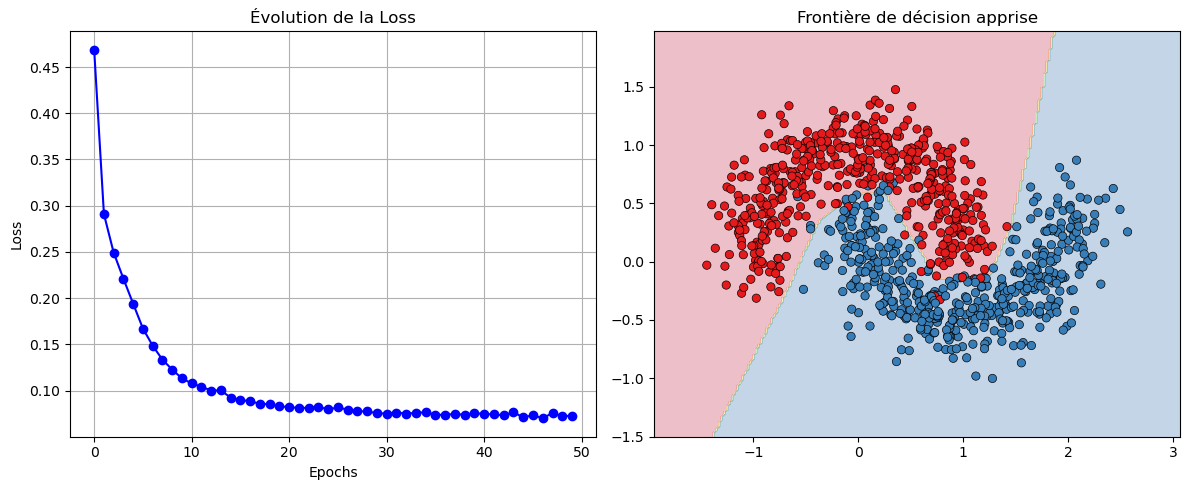

In [10]:
plt.figure(figsize=(12, 5))

# Graphique 1 : Courbe de perte
plt.subplot(1, 2, 1)
plt.plot(history, marker="o", color="b")
plt.title("Évolution de la Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

# Graphique 2 : Frontières de décision du modèle
plt.subplot(1, 2, 2)
model.eval()
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
)
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)

with torch.no_grad():
  preds = model(grid_tensor).cpu().numpy()
  zz = np.argmax(preds, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, zz, alpha=0.3, cmap=plt.cm.Spectral)
sns.scatterplot(
    x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k", legend=False
)
plt.title("Frontière de décision apprise")

plt.tight_layout()
plt.show()